In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Example of the derivative

In [2]:
# Take any simple function:
def f(x):
    return 3*x**2-4*x+5

f(3)

20

In [3]:
# Generate random array of xs:
xs = np.arange(-5, 5, 0.25)
# populatate ys:
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

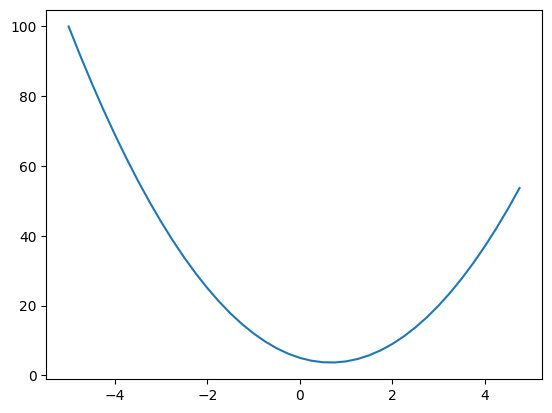

In [4]:
# plot the resulted curve:
plt.plot(xs, ys)

In [5]:
# now find derivative:

h = 0.0000001
a = 3
dx_dy = (f(a+h)-f(a))/h
dx_dy

14.000000305713911

# Let's go more complex

In [6]:
# input values:
a = 2.0
b = -3.0
c = 10.0

# function:
d1 = a*b + c
d1

4.0

In [7]:
h = 0.001
# derivative of d with respect to a:
a+=h
d2 = a*b + c
d2

3.997

In [8]:
# slope of d2:
(d2-d1)/h

-3.0000000000001137

In [9]:
# derivative of d with respect to b:
a -= h
b += h
d3 = a*b + c
print("derivative of d with respect to b:", d3)

# slope of d3:
print(f"slope of d3: {(d3-d1)/h}")

derivative of d with respect to b: 4.002
slope of d3: 1.9999999999997797


In [10]:
# derivative of d with respect to c:
b -= h
c += h
d4 = a*b + c
print("derivative of d with respect to c:", d4)

# slope of d4:
print(f"slope of d4: {(d4-d1)/h}")

derivative of d with respect to c: 4.0009999999999994
slope of d4: 0.9999999999994458


# Micrograg Value Class

In [20]:
class Value():
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __add__(self, other):
        other = other if isinstance (other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backwards():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backwards
        return out

    def __mul__(self, other):
        other = other if isinstance (other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _backwards():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backwards
        return out

    def __pow__(self, other):
        assert isinstance (other, (int, float)) # other should be only int or float
        out = Value(self.data**other, _children=(self, ), _op="power")
        def _backwards():
            self.grad += (other * (self.data ** (other-1))) * out.grad
        out._backward = _backwards
        return out

    def tanh(self):
        x = self.data
        expression = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(expression, _children=(self, ), _op="tanh")
        def _backwards():
            self.grad += (1-expression**2) * out.grad
        out._backward = _backwards
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), _children=(self, ), _op="exp")
        def _backwards():
            self.grad += out.data * out.grad
        out._backward = _backwards
        return out

    def backward(self):
        topological_sorted = []
        visited = set()
        def topo_sort(self):
            if self not in visited:
                visited.add(self)
                for child in self._prev:
                    topo_sort(child)
                topological_sorted.append(self)

        topo_sort(self)
        self.grad = 1.0
        for node in reversed(topological_sorted):
            node._backward()

    def __neg__ (self): # -self
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)

    def __truediv__(self, other): # self/other
        return self*other**-1

    def __rmul__(self, other): # self*other
        return self * other

    def __radd__(self, other): # self + other
        return self + other
        
    def __repr__(self):
        return f"Value: {self.data}"

In [21]:
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label = "c")

In [66]:
e = a*b; e.label = "e"
d = e+c; d.label = "d"
f = Value(-2.0, label = "f")
L = f*d; L.label = "L"

In [67]:
print("d value:", d)
print("children d:", d._prev)
print("d operation:", d._op)

d value: Value: 4.0
children d: {Value: -6.0, Value: 10.0}
d operation: +


# Visualize using graphviz

In [68]:
#!pip install graphviz

In [3]:
from graphviz import Digraph

In [4]:
def trace(graph):
    nodes, edges = set(), set()
    def build(element):
        if element not in nodes:
            nodes.add(element)
            for child in element._prev:
                edges.add((child, element))
                build(child)
    build(graph)
    return nodes, edges

def drow_dot(root):
    # initialize graph
    graph = Digraph(format="svg", graph_attr={'rankdir':'LR'})
    # fetch nodes and edges in 2 sets
    nodes, edges = trace(root)
    for node in nodes: # iterate over nodes set
        # get unique identifier of the node
        node_id = str(id(node))
        # creates a node instance: node id, node data
        graph.node(name = node_id, label=f"{node.label}| value {node.data:.4f}|grad {node.grad:.4f}", shape="record") # rectangular shape
        if node._op: # if we know operations of the node
            # create new node with id: "node_id operation" and label "what operation"
            graph.node(name = node_id + node._op, label=node._op)
            # create edge to connect 2 nodes: connect "node_id operation, the letter" with "node_id the first"
            graph.edge(node_id + node._op, node_id)

    for n1, n2 in edges: # iterate over edges set (child-parent node values there)
        # connect child to the parent operation (where it came from)
        child_node_id = str(id(n1))
        parent_node_id = str(id(n2))
        parent_node_operation = n2._op # str
        node2 = parent_node_id+parent_node_operation
        graph.edge(child_node_id, node2)

    return graph


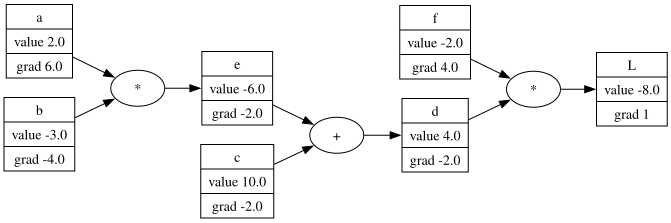

In [77]:
graph = drow_dot(L)
graph

In [79]:
# Increase the L by increasing children in the direction of the gradient:
h = 0.01
a.data += h*a.grad
b.data += h*b.grad
c.data += h*c.grad
f.data += h*f.grad

L_new = (a.data*b.data+c.data)*f.data
L_new

-7.215871776

# Manual backpropagation

In [59]:
def check():
    h = 0.001

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label = "c")
    e = a*b; e.label = "e"
    d = e+c; d.label = "d"
    f = Value(2.0, label = "f")
    L = f*d; L.label = "L"
    L1 = L.data

    a = Value(2.0+h, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label = "c")
    e = a*b; e.label = "e"
    d = e+c; d.label = "d"
    f = Value(2.0, label = "f")
    L = f*d; L.label = "L"
    L2 = L.data

    print((L2-L1)/h)

check()

-6.000000000000227


In [76]:
L.grad = 1
# L = f*d
# dL/df = d
f.grad = d.data

# dL/dd = f
d.grad = f.data

# e+c = d
# dd/de = 1
# dL/de = dd/de * dL/dd
e.grad = 1*d.grad

# dd/dc = 1
# dL/dc = dd/dc * dL/dd
c.grad = 1*d.grad

# a*b=e
# de/da = b
# dL/da = de/da * dL/de
a.grad = b.data*e.grad

# de/db = a
# dL/db = de/db * dL/de
b.grad = a.data*e.grad


# Neuron

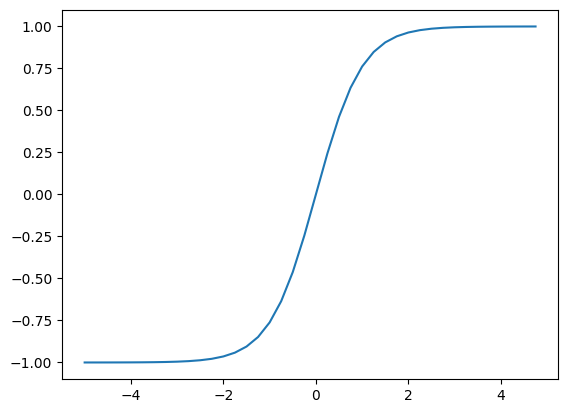

In [86]:
# example of the activation function - this is just sqaush the output y
x = np.arange(-5,5,0.25)
y = np.arange(-5,5,0.25)
plt.plot(x, np.tanh(y))

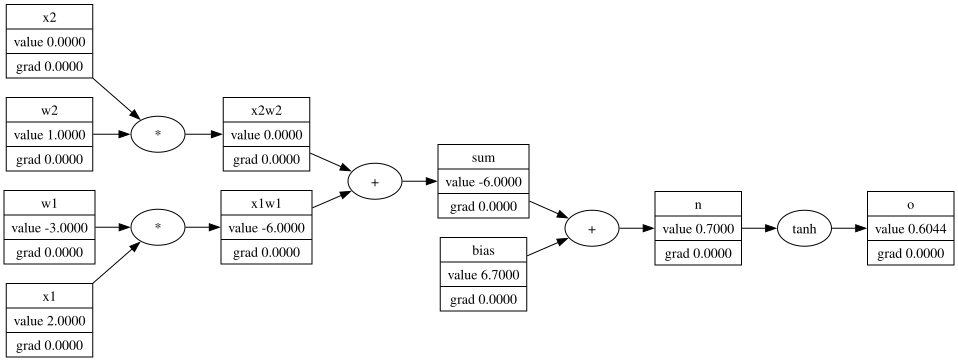

In [225]:
# building simple neuron without activation function, just n = x1*w1 + x2*w2 + b

# inputs
x1 = Value(2.0, label="x1")
w1 = Value(-3.0, label="w1")

x2 = Value(0.0, label="x2")
w2 = Value(1.0, label="w2")

b = Value(6.7, label="bias")

# output
x1w1 = x1*w1; x1w1.label="x1w1"
x2w2 = x2*w2; x2w2.label="x2w2"
x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label="sum"
n = x1w1_x2w2 + b; n.label="n"

# adding tanh activation to the neuron:
o = n.tanh(); o.label = "o"

# plot
drow_dot(o)

In [140]:
# calculating gradients

# do/do = 1.0
o.grad = 1.0

# o = tanh(n)
# do/dn = 1-(tanh(n))^2
n.grad = 1-(o.data)**2

# bias + sum = n
# do/dbias = dn/dbias * do/dn
# dn/dbias = 1
b.grad = 1 * n.grad

# bias + sum = n
# do/dsum = dn/dsum * do/dn
# dn/dsum = 1
sum.grad = 1 * n.grad

# x2w2 + x1w1 = sum
# do/dx2w2 = dsum/dx2w2 * do/dsum
# dsum/dx2w2 = 1
x2w2.grad = 1*sum.grad

# x1w1 + x1w1 = sum
# do/dx1w1 = dsum/dx1w1 * do/dsum
# dsum/dx1w1 = 1
x1w1.grad = 1*sum.grad

# x2 * w2 = x2w2
# do/dx2 = dx2w2/dx2 * do/dx2w2
# dx2w2/dx2 = w2
x2.grad = w2.data * x2w2.grad

# x2 * w2 = x2w2
# do/dw2 = dx2w2/dw2 * do/dx2w2
# dx2w2/dx2 = x2
w2.grad = x2.data * x2w2.grad

# x1 * w1 = x1w1
# do/dx1 = dx1w1/dx1 * do/dx1w1
# dx1w1/dx1 = w1
x1.grad = w1.data * x1w1.grad

# x1 * w1 = x1w1
# do/dw1 = dx1w1/dw1 * do/dx1w1
# dx1w1/dx1 = x1
w1.grad = x1.data * x1w1.grad

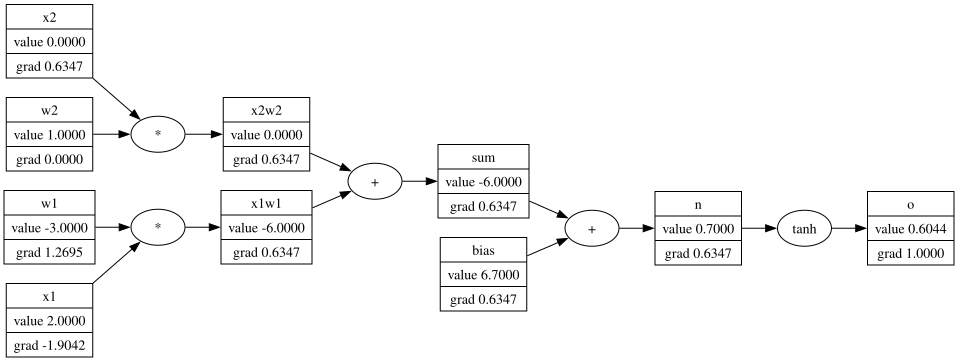

In [142]:
drow_dot(o)

# Automated backpropagation

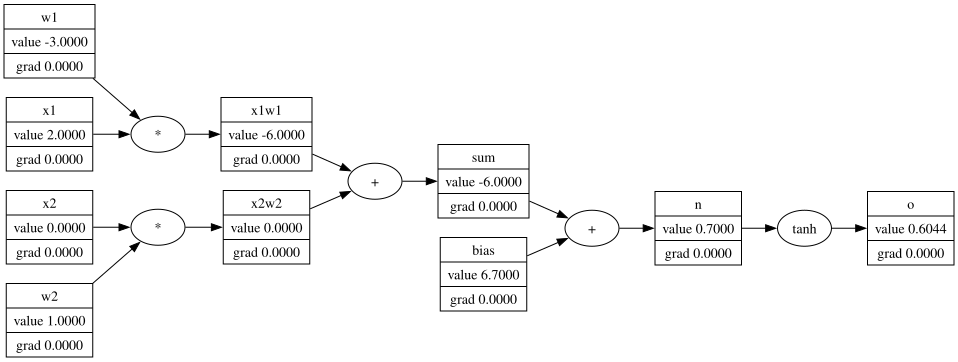

In [295]:
# building simple neuron without activation function, just n = x1*w1 + x2*w2 + b

# inputs
x1 = Value(2.0, label="x1")
w1 = Value(-3.0, label="w1")

x2 = Value(0.0, label="x2")
w2 = Value(1.0, label="w2")

b = Value(6.7, label="bias")

# output
x1w1 = x1*w1; x1w1.label="x1w1"
x2w2 = x2*w2; x2w2.label="x2w2"
x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label="sum"
n = x1w1_x2w2 + b; n.label="n"

# adding tanh activation to the neuron:
o = n.tanh(); o.label = "o"

# plot
drow_dot(o)

In [296]:
o.backward()

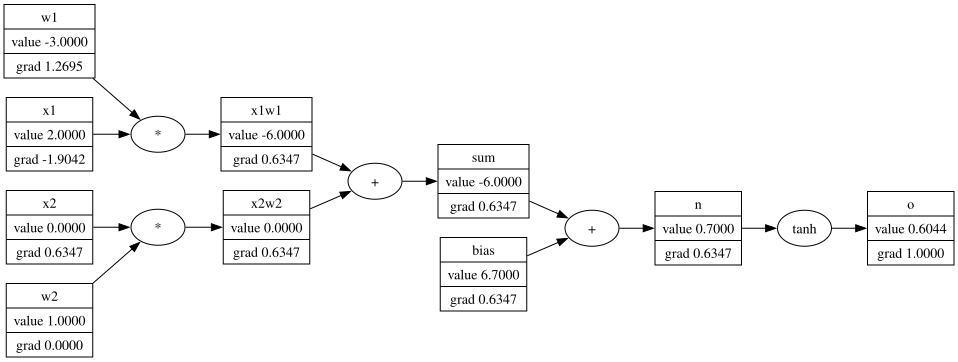

In [297]:
drow_dot(o)

# Division, Pover, Negation, Exp

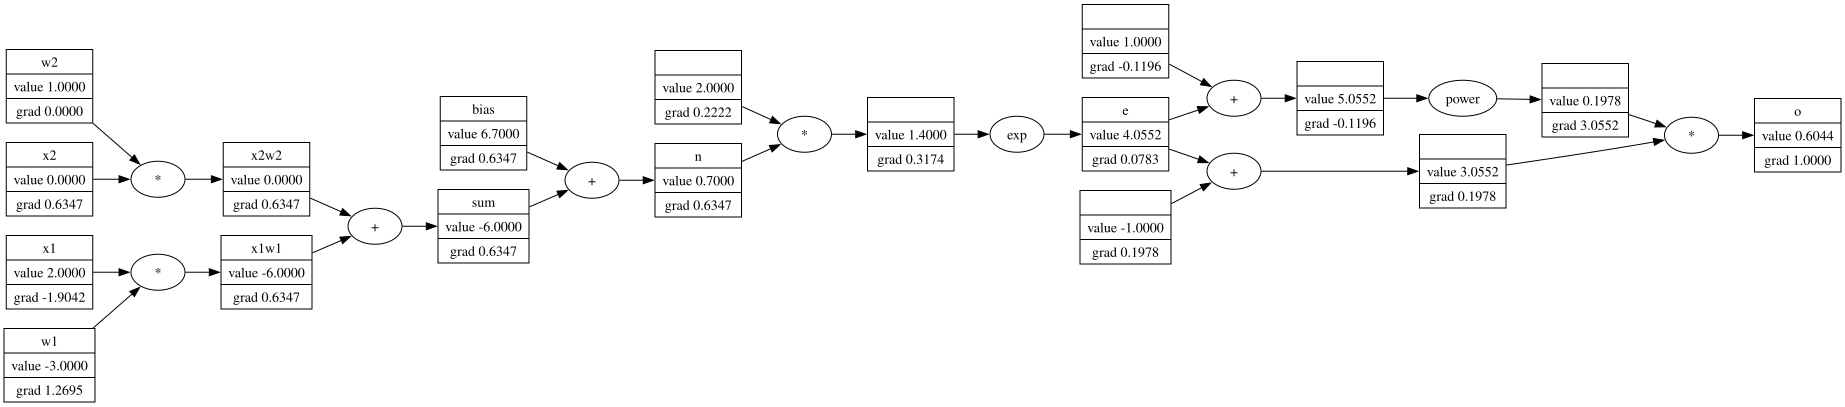

In [300]:
# building simple neuron without activation function, just n = x1*w1 + x2*w2 + b

# inputs
x1 = Value(2.0, label="x1")
w1 = Value(-3.0, label="w1")

x2 = Value(0.0, label="x2")
w2 = Value(1.0, label="w2")

b = Value(6.7, label="bias")

# output
x1w1 = x1*w1; x1w1.label="x1w1"
x2w2 = x2*w2; x2w2.label="x2w2"
x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label="sum"
n = x1w1_x2w2 + b; n.label="n"

# adding tanh activation to the neuron:
# e = e^2x, where x is n
#e = (2*n).exp()
e = (2*n).exp(); e.label = "e"
o = (e-1)/(e+1); o.label = "o"

# backpropagation
o.backward()
# plot
drow_dot(o)

# Torch Analog

In [303]:
#!pip install torch

In [5]:
import torch

In [319]:
# building simple neuron without activation function, just n = x1*w1 + x2*w2 + b

# inputs
x1 = torch.Tensor([2.0]).double() ; x1.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w2.requires_grad = True

x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True

b = torch.Tensor([6.7]).double(); b.requires_grad = True

# output
n = x1*w1 + x2*w2 + b

# adding tanh activation to the neuron:
o = torch.tanh(n)

print(o.item())

# backpropagation
n.retain_grad()
o.retain_grad()
o.backward()

0.6043676560501806


In [321]:
n.grad.item()

0.6347397363204106

# MLP

In [24]:
import random
class Neuron:
    def __init__(self, nin): # nin = number of weights inputed into one neuron
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # x1*w1+b
        zipped = (zip(self.w, x))
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

class Layer:
    def __init__(self, nin, nout): # nout = number of neurons in the single layer
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

class MLP:
    def __init__(self, nin, nouts):
        size = [nin] + nouts
        self.layers = [Layer(size[i], size[i+1])for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


In [25]:
# 3 input neurons
# 2 layers of 4 neurons
# output unit

# input:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])

In [26]:
n(x)

Value: -0.4392736945119701

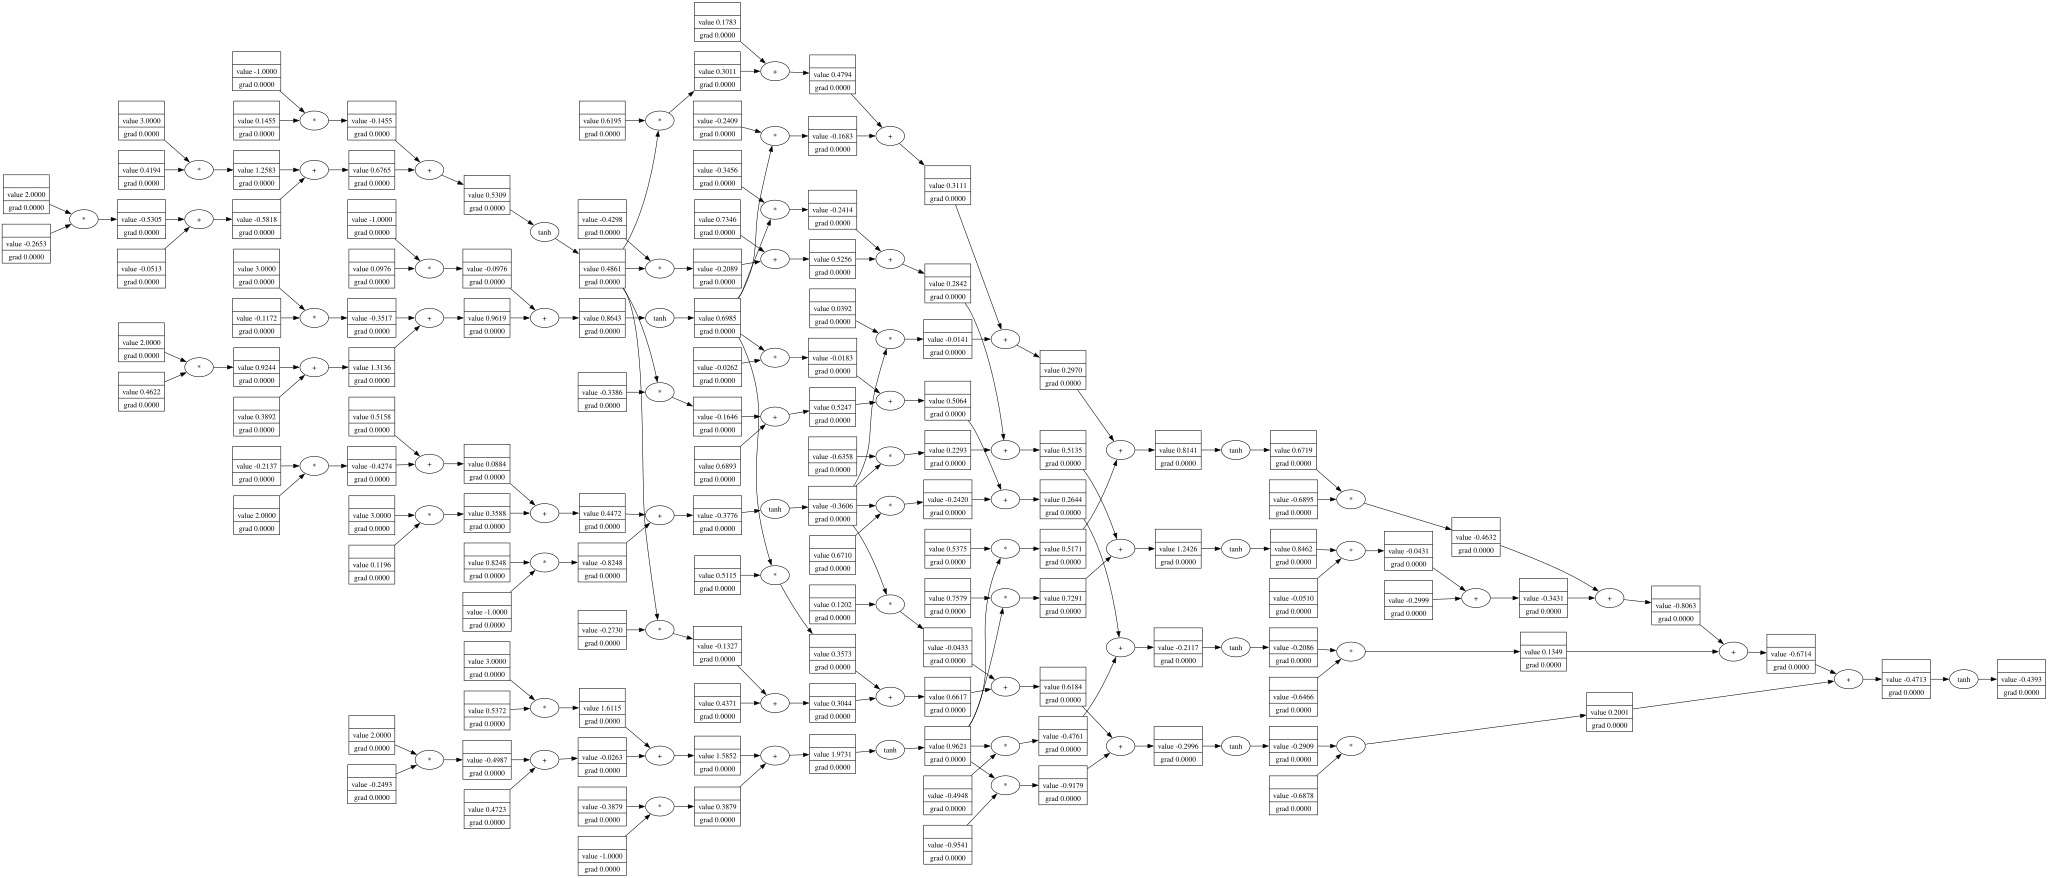

In [27]:
drow_dot(n(x))

# Loss - Mean Squared Error (MSE)

In [28]:
# given 4 inputs:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
# desired outputs:
ys = [1.0, -1.0, -1.0, 1.0]
# run forward pass for the given inputs:
ypred = [n(x) for x in xs]
ypred

[Value: -0.4392736945119701,
 Value: -0.7706871837608195,
 Value: -0.8645744953855863,
 Value: -0.5282601401211923]

In [29]:
loss = sum(((y_pred - y_target)**2 for y_pred, y_target in zip(ypred, ys)))
loss

Value: 4.478012258588995

In [30]:
# loss now is just another node
# call backpropagation on it
loss.backward()

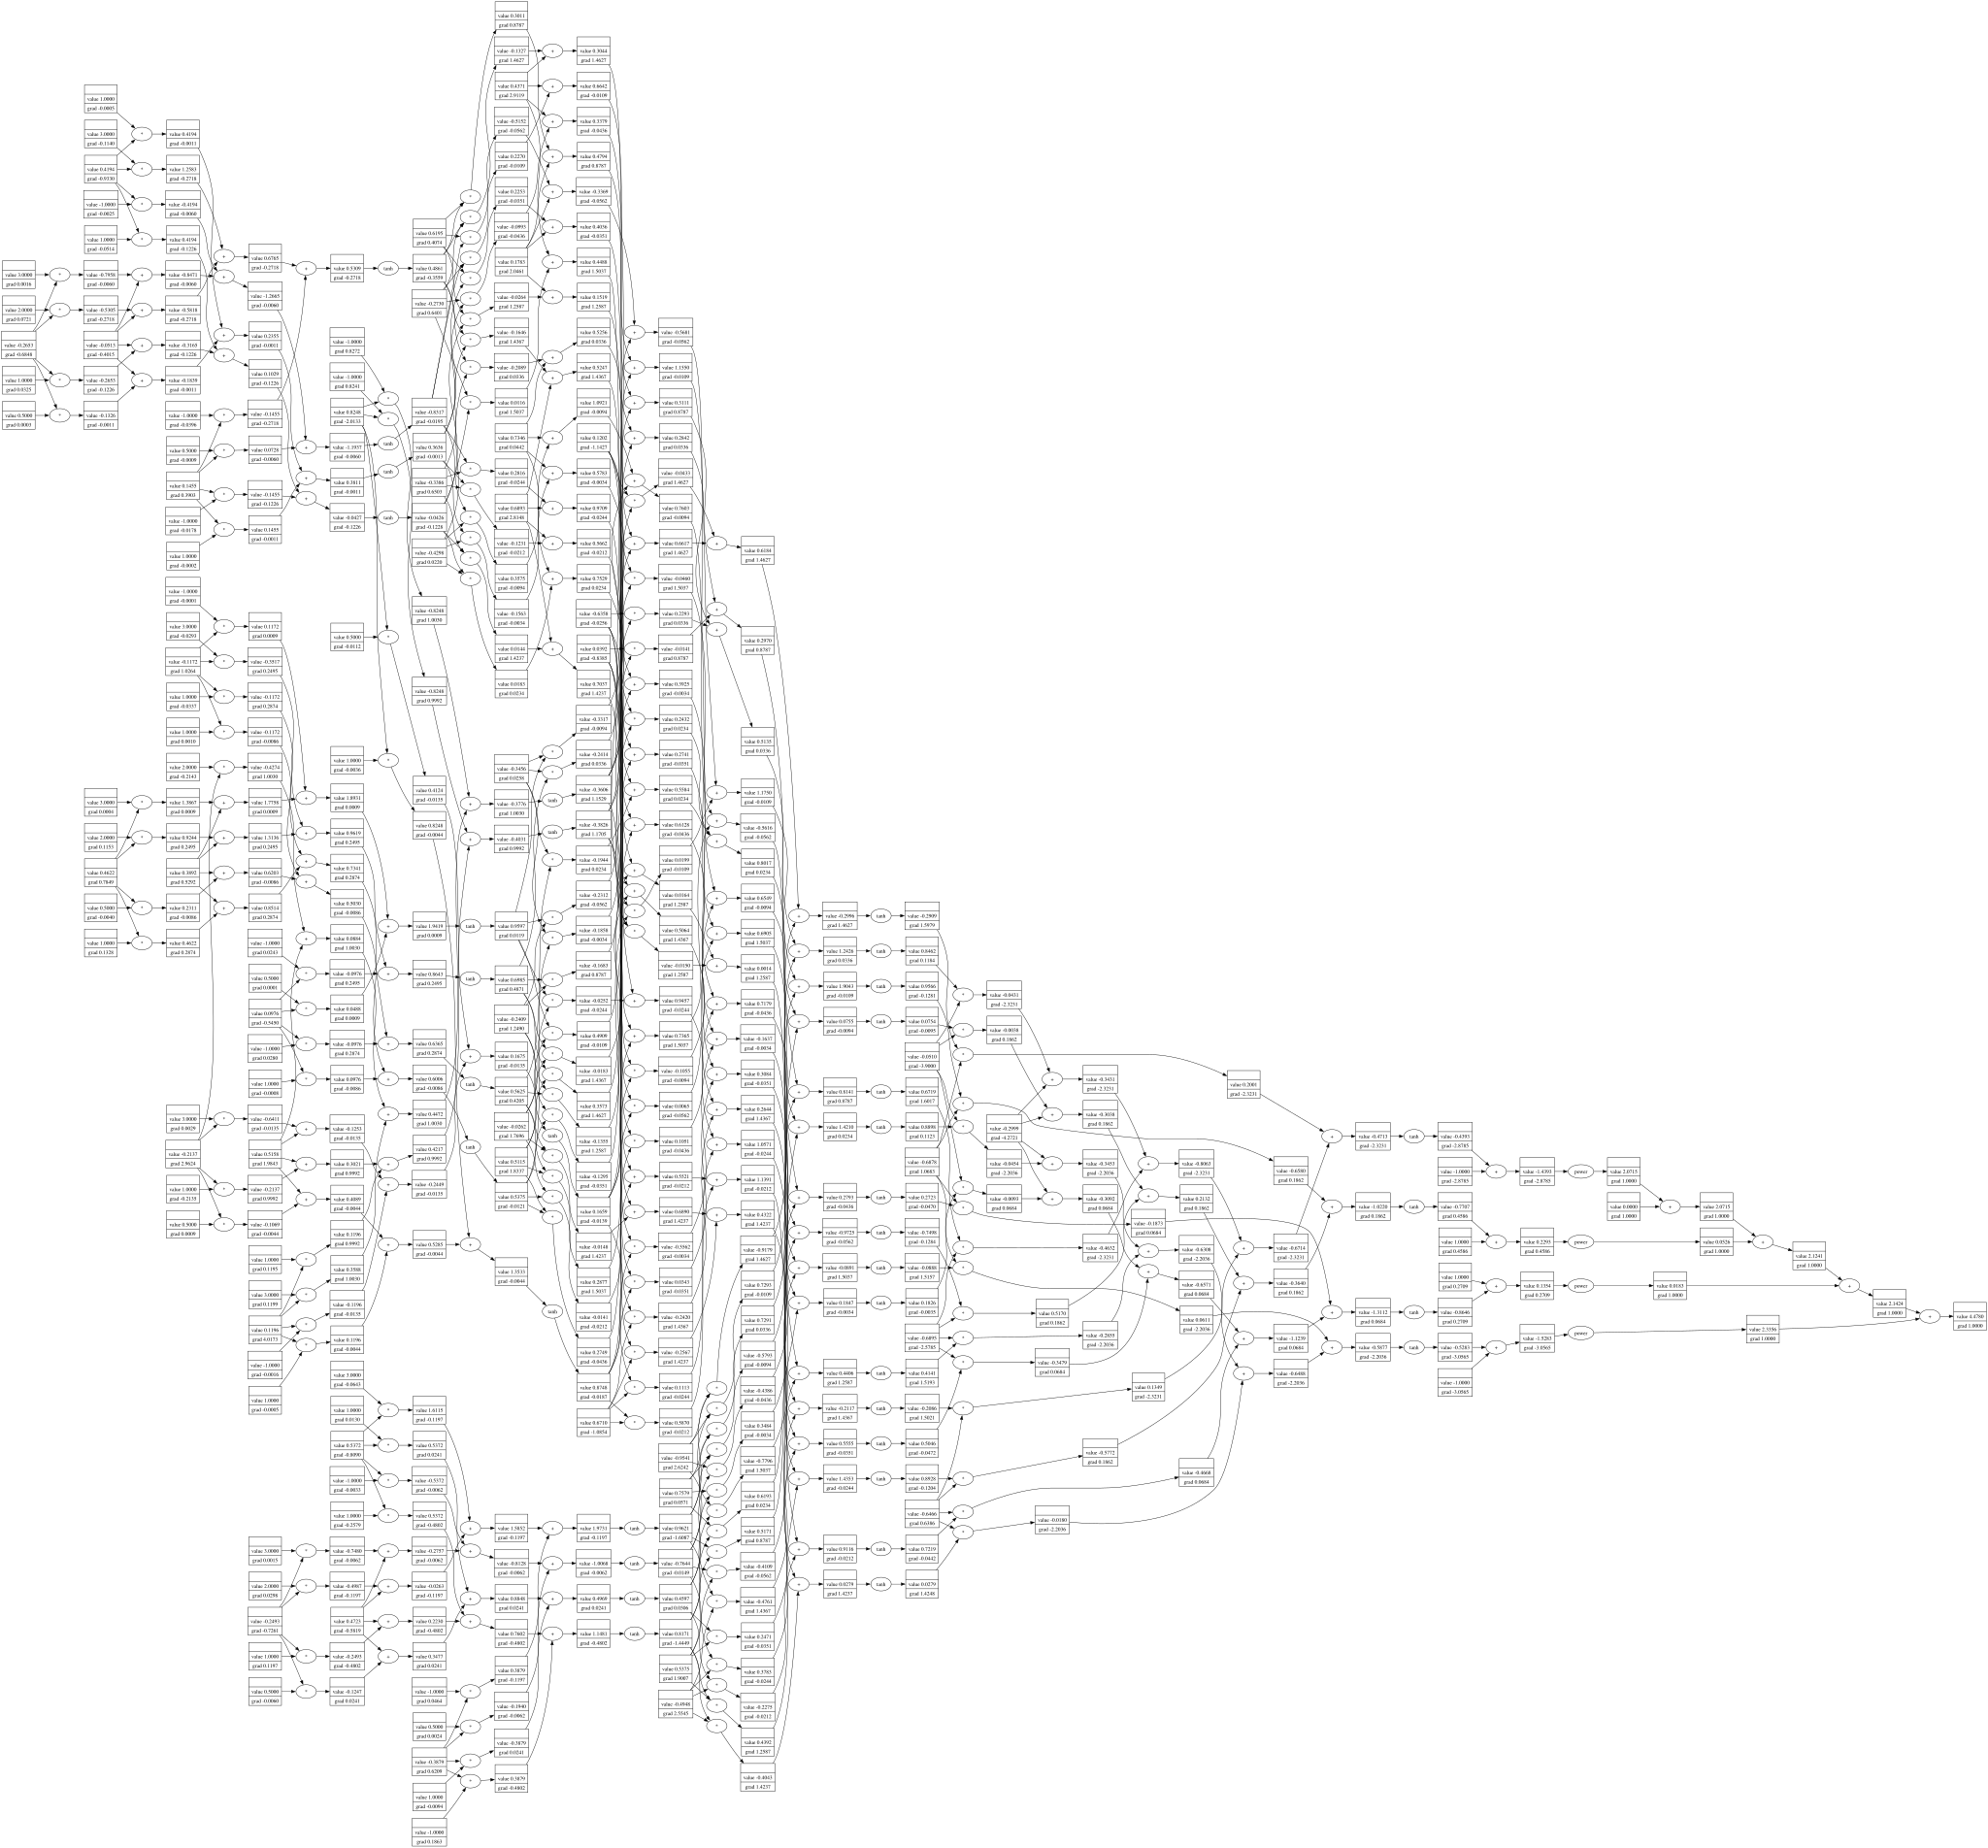

In [31]:
# now let's see the grads:
drow_dot(loss)

In [33]:
n.layers[0].neurons[0].w[0].grad

-0.6847546173703932